In [1]:
# Install required packages
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'wfdb', 'tqdm', '--quiet'])
print('Packages ready.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 10.4 MB/s eta 0:00:00
Packages ready.


In [2]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


## 1. Imports & Environment Setup

In [3]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
from sklearn.preprocessing import MinMaxScaler
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

print('All imports OK.')

All imports OK.


## 2. Paper Configuration (Section 3, Dudukcu et al. 2023)

In [4]:
# ── MIT-BIH Arrhythmia Database path ────────────────────────────────────────
# Update this to the local path where you extracted the MIT-BIH database.
DATA_DIR = r"/kaggle/input/datasets/rracer17/mit-bih-mitdb/mit-bih-arrhythmia-database-1.0.0"

# ── Exact constants from the paper (Section 3) ───────────────────────────────
FS           = 360        # sampling frequency (360 samples/second)
TOTAL_STEPS  = 100_000    # '100,000 time-step ECG data' per patient
TRAIN_STEPS  = 40_000     # '40,000 time-steps for training'
VAL_STEPS    = 10_000     # '10,000 time-steps for validation'
TEST_STEPS   = 50_000     # '50,000 time-steps as test data'

LOOKBACK     = 10         # '10-time step history windows'
HORIZON      = 1          # 'one time-step of prediction horizon'

# ── 21 patients: full MIT-BIH set MINUS patients 111 and 118 ────────────────
# Paper: 'Patient 111 and Patient 118 from 23 patients were excluded
#         ... because models could not be trained correctly'
PATIENTS = [
    '100', '101', '102', '103', '104', '105',
    '106', '107', '108', '109', '112', '113',
    '114', '115', '116', '117', '119',
    '121', '122', '123', '124'
]
assert len(PATIENTS) == 21, f'Expected 21 patients, got {len(PATIENTS)}'

print(f'Patients         : {len(PATIENTS)}')
print(f'Sampling freq    : {FS} Hz')
print(f'Total steps/pt   : {TOTAL_STEPS:,}')
print(f'Train/Val/Test   : {TRAIN_STEPS:,} / {VAL_STEPS:,} / {TEST_STEPS:,}')
print(f'Lookback window  : {LOOKBACK} steps  →  {LOOKBACK/FS*1000:.1f} ms')
print(f'Pred horizon     : {HORIZON} step   →  {HORIZON/FS*1000:.1f} ms')
print(f'Excluded         : 111, 118 (paper: outlier values during benchmarking)')

Patients         : 21
Sampling freq    : 360 Hz
Total steps/pt   : 100,000
Train/Val/Test   : 40,000 / 10,000 / 50,000
Lookback window  : 10 steps  →  27.8 ms
Pred horizon     : 1 step   →  2.8 ms
Excluded         : 111, 118 (paper: outlier values during benchmarking)


## 3. Data Loading & Preprocessing

Pipeline follows Section 3 of the paper exactly:
1. Load MLII lead from MIT-BIH Arrhythmia Database using `wfdb`.
2. Truncate / pad to exactly `TOTAL_STEPS` samples.
3. Split: train (0–40k), validation (40k–50k), test (50k–100k).
4. Min-Max normalise — scaler fitted on **train only** to prevent leakage.
5. Build sliding-window sequences: X = 10 steps, y = next step (1-step-ahead).

In [5]:
def load_ecg_signal(record_id: str, data_dir: str, n_steps: int = 100_000) -> np.ndarray:
    """
    Load the MLII lead (or first available lead) from a MIT-BIH record
    and return exactly n_steps samples.

    Paper (Section 3.1): 'digitizing the two-channel ambulatory ECG recordings
    of a 24-hour period with a sampling frequency of 360 samples per second.'
    The amplitude is estimated 2 ms ahead using 28 ms history windows.
    Here we load the raw signal; history windowing is applied in make_sequences().
    """
    path = os.path.join(data_dir, record_id)
    rec  = wfdb.rdrecord(path)

    # Prefer MLII lead; fall back to first available channel
    sig_names_upper = [s.upper() for s in rec.sig_name]
    ch = sig_names_upper.index('MLII') if 'MLII' in sig_names_upper else 0

    signal = rec.p_signal[:, ch].astype(np.float32)

    # Pad with the last value if the recording is shorter than n_steps
    if len(signal) < n_steps:
        pad = np.full(n_steps - len(signal), signal[-1], dtype=np.float32)
        signal = np.concatenate([signal, pad])

    return signal[:n_steps]


def preprocess_patient(
    signal: np.ndarray,
    train_steps: int = 40_000,
    val_steps:   int = 10_000,
) -> tuple:
    """
    Split signal into train / val / test, then apply Min-Max normalisation.

    Paper (Section 3): 'For both datasets, 40,000 time-steps are separated
    for training data, 10,000 time-steps for validation data, and 50,000
    time-steps as test data.'

    Scaler is fitted on the training partition only to avoid data leakage.
    Returns: (train_norm, val_norm, test_norm, fitted_scaler)
    """
    train_end = train_steps
    val_end   = train_steps + val_steps

    train_raw = signal[:train_end]          # 0     – 39,999
    val_raw   = signal[train_end:val_end]   # 40,000 – 49,999
    test_raw  = signal[val_end:]            # 50,000 – 99,999

    scaler     = MinMaxScaler(feature_range=(0, 1))
    train_norm = scaler.fit_transform(train_raw.reshape(-1, 1)).flatten()
    val_norm   = scaler.transform(val_raw.reshape(-1, 1)).flatten()
    test_norm  = scaler.transform(test_raw.reshape(-1, 1)).flatten()

    return train_norm, val_norm, test_norm, scaler


def make_sequences(
    signal:   np.ndarray,
    lookback: int = 10,
    horizon:  int = 1,
) -> tuple:
    """
    Build sliding-window (X, y) pairs for supervised time-series prediction.

    Paper (Section 3.2): '10-time step history windows for one time-step of
    prediction horizon' and 'the amplitude of the signal was estimated 2 ms
    ahead by using input data sequences with 28 ms history window.'
    (28 ms @ 360 Hz ≈ 10 samples; 2 ms @ 360 Hz ≈ 1 sample ahead)

    X[i] = signal[i : i+lookback]   shape (lookback,)
    y[i] = signal[i + lookback]     scalar
    """
    X, y = [], []
    for i in range(len(signal) - lookback - horizon + 1):
        X.append(signal[i : i + lookback])
        y.append(signal[i + lookback])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


print('Preprocessing functions defined.')
print(f'  load_ecg_signal()   — reads MLII lead, truncates/pads to {TOTAL_STEPS:,} steps')
print(f'  preprocess_patient() — splits {TRAIN_STEPS:,}/{VAL_STEPS:,}/{TEST_STEPS:,}, MinMax-normalises')
print(f'  make_sequences()    — sliding window: X={LOOKBACK} steps → y=1 step ahead')

Preprocessing functions defined.
  load_ecg_signal()   — reads MLII lead, truncates/pads to 100,000 steps
  preprocess_patient() — splits 40,000/10,000/50,000, MinMax-normalises
  make_sequences()    — sliding window: X=10 steps → y=1 step ahead


In [6]:
# patient_data[rid] contains the preprocessed split arrays and the fitted scaler.
# Structure: {'X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test', 'scaler'}
patient_data = {}

print(f'Loading and preprocessing {len(PATIENTS)} patients...\n')
for rid in tqdm(PATIENTS, desc='Patients'):
    # Step 1 — load raw signal
    signal = load_ecg_signal(rid, DATA_DIR, n_steps=TOTAL_STEPS)

    # Step 2 — split + normalise
    tr, vl, te, sc = preprocess_patient(signal, TRAIN_STEPS, VAL_STEPS)

    # Step 3 — build sliding-window sequences for each partition
    X_tr, y_tr = make_sequences(tr, LOOKBACK, HORIZON)
    X_vl, y_vl = make_sequences(vl, LOOKBACK, HORIZON)
    X_te, y_te = make_sequences(te, LOOKBACK, HORIZON)

    patient_data[rid] = {
        'X_train': X_tr, 'y_train': y_tr,
        'X_val'  : X_vl, 'y_val'  : y_vl,
        'X_test' : X_te, 'y_test' : y_te,
        'scaler' : sc,
    }
    tqdm.write(
        f'  Patient {rid:>3s} | '
        f'train={X_tr.shape}  val={X_vl.shape}  test={X_te.shape}'
    )

print('\nAll patients loaded.')

Loading and preprocessing 21 patients...



Patients:   0%|          | 0/21 [00:00<?, ?it/s]

  Patient 100 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 101 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 102 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 103 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 104 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 105 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 106 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 107 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 108 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 109 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 112 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 113 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 114 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 115 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 116 | train=(39990, 10)  val=(9990, 10

## 4. Preprocessing Verification

Sanity-check that every patient's arrays match the shapes and value ranges
expected from the paper's description.

In [7]:
# ── Expected shapes from paper ───────────────────────────────────────────────
# train partition: 40,000 samples  → sequences: 40,000 - 10 - 1 + 1 = 39,990
# val   partition: 10,000 samples  →            10,000 - 10 - 1 + 1 =  9,990
# test  partition: 50,000 samples  →            50,000 - 10 - 1 + 1 = 49,990
EXP_TRAIN_N = TRAIN_STEPS - LOOKBACK - HORIZON + 1   # 39,990
EXP_VAL_N   = VAL_STEPS   - LOOKBACK - HORIZON + 1   #  9,990
EXP_TEST_N  = TEST_STEPS  - LOOKBACK - HORIZON + 1   # 49,990

print(f'Expected sequence counts:')
print(f'  Train : {EXP_TRAIN_N:,}')
print(f'  Val   : {EXP_VAL_N:,}')
print(f'  Test  : {EXP_TEST_N:,}\n')

all_ok = True
rows = []
for rid in PATIENTS:
    d = patient_data[rid]
    shape_ok  = (
        d['X_train'].shape == (EXP_TRAIN_N, LOOKBACK) and
        d['X_val'].shape   == (EXP_VAL_N,   LOOKBACK) and
        d['X_test'].shape  == (EXP_TEST_N,  LOOKBACK)
    )
    # After MinMax normalisation all values should be in [0, 1] for train
    scale_ok  = (
        float(d['X_train'].min()) >= -1e-6 and
        float(d['X_train'].max()) <=  1 + 1e-6
    )
    nan_ok    = not (np.isnan(d['X_train']).any() or np.isnan(d['X_test']).any())
    status    = '✅' if (shape_ok and scale_ok and nan_ok) else '❌'
    if not (shape_ok and scale_ok and nan_ok):
        all_ok = False
    rows.append({
        'Patient' : rid,
        'Train X' : str(d['X_train'].shape),
        'Val X'   : str(d['X_val'].shape),
        'Test X'  : str(d['X_test'].shape),
        'Scale OK': '✅' if scale_ok else '❌',
        'NaN free': '✅' if nan_ok  else '❌',
        'Status'  : status,
    })

df_check = pd.DataFrame(rows).set_index('Patient')
print(df_check.to_string())
print()
if all_ok:
    print('✅  All 21 patients pass shape, scale, and NaN checks.')
else:
    print('❌  One or more patients failed verification — check DATA_DIR and signal lengths.')

Expected sequence counts:
  Train : 39,990
  Val   : 9,990
  Test  : 49,990

             Train X       Val X       Test X Scale OK NaN free Status
Patient                                                               
100      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
101      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
102      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
103      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
104      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
105      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
106      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
107      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
108      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
109      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
112      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅


## 5. Signal Visualisation (Sanity Check)

Plot a representative segment from Patient 103 across all three partitions
to confirm the normalised signal looks physiologically plausible before training.

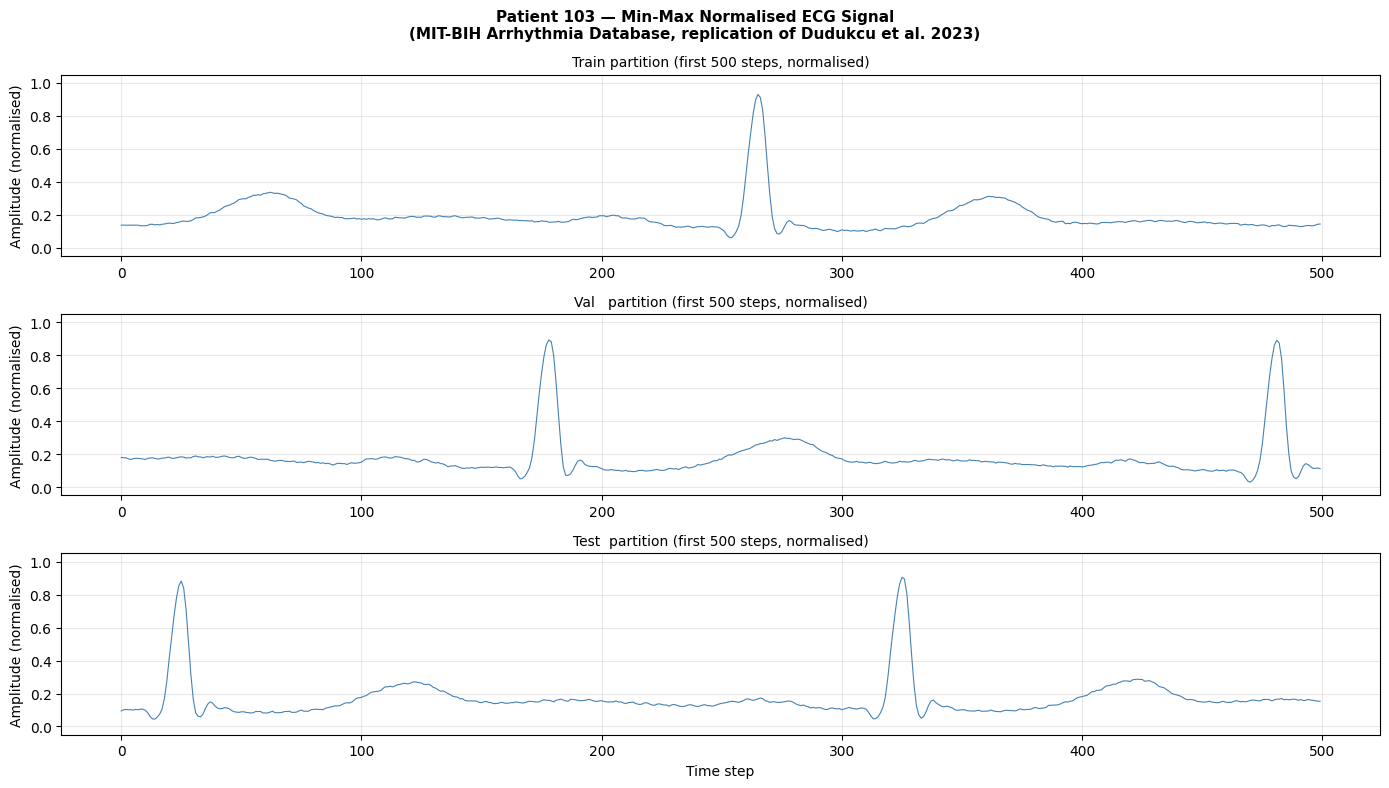

Plot saved to patient103_preprocessed.png


In [8]:
DEMO_PATIENT = '103'
d = patient_data[DEMO_PATIENT]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=False)

segments = [
    ('Train partition (first 500 steps, normalised)', d['X_train'][:500, 0]),
    ('Val   partition (first 500 steps, normalised)', d['X_val'][:500, 0]),
    ('Test  partition (first 500 steps, normalised)', d['X_test'][:500, 0]),
]
for ax, (title, seg) in zip(axes, segments):
    ax.plot(seg, linewidth=0.8, color='steelblue')
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Amplitude (normalised)')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time step')
fig.suptitle(
    f'Patient {DEMO_PATIENT} — Min-Max Normalised ECG Signal\n'
    f'(MIT-BIH Arrhythmia Database, replication of Dudukcu et al. 2023)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('patient103_preprocessed.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to patient103_preprocessed.png')

## 6. Preprocessing Summary

Aggregate statistics across all 21 patients to confirm consistency
before handing off to model training.

In [9]:
summary_rows = []
for rid in PATIENTS:
    d = patient_data[rid]
    summary_rows.append({
        'Patient'          : rid,
        'Train samples'    : d['X_train'].shape[0],
        'Val samples'      : d['X_val'].shape[0],
        'Test samples'     : d['X_test'].shape[0],
        'Train min'        : round(float(d['X_train'].min()), 4),
        'Train max'        : round(float(d['X_train'].max()), 4),
        'Test min'         : round(float(d['X_test'].min()),  4),
        'Test max'         : round(float(d['X_test'].max()),  4),
        'Scaler min (mV)'  : round(float(d['scaler'].data_min_[0]), 4),
        'Scaler max (mV)'  : round(float(d['scaler'].data_max_[0]), 4),
    })

df_summary = pd.DataFrame(summary_rows).set_index('Patient')
print('Preprocessing summary (all 21 patients):')
display(df_summary)

print(f'\nX shape per sample : ({LOOKBACK},)  →  ready for model input')
print(f'y shape per sample : scalar (1-step-ahead amplitude)')
print(f'\npreprocessing complete — patient_data dict is ready for training.')

Preprocessing summary (all 21 patients):


,Train samples,Val samples,Test samples,Train min,Train max,Test min,Test max,Scaler min (mV),Scaler max (mV)
Patient,,,,,,,,,
100,39990,9990,49990,0.0,1.0,0.0000,1.0659,-0.695,1.125
101,39990,9990,49990,0.0,1.0,-0.6421,1.1146,-1.130,2.055
102,39990,9990,49990,0.0,1.0,0.2442,0.8797,-1.410,1.375
103,39990,9990,49990,0.0,1.0,-0.0036,1.0267,-0.760,2.045
104,39990,9990,49990,0.0,1.0,-0.2539,1.0875,-1.195,1.720
105,39990,9990,49990,0.0,1.0,-0.0018,1.0018,-0.790,1.965
106,39990,9990,49990,0.0,1.0,0.0134,0.9946,-1.520,2.200
107,39990,9990,49990,0.0,1.0,0.0330,0.9280,-3.105,2.800
108,39990,9990,49990,0.0,1.0,-0.1002,0.9087,-1.165,1.080



X shape per sample : (10,)  →  ready for model input
y shape per sample : scalar (1-step-ahead amplitude)

preprocessing complete — patient_data dict is ready for training.


---

# TCN Multi-Step Forecasting

Three forecasting strategies across horizons **10, 20, 50** steps:

| Strategy | Description |
|----------|-------------|
| **Recursive** | Train 1-step TCN, iterate H times feeding predictions back as input |
| **Direct** | Train H independent TCN models, each predicting one future step |
| **Multi-Output** | Single TCN predicting all H steps at once (MIMO) |

Metrics: RMSE · MAE · R² · Computation Time

In [10]:
import time, gc
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv1D, Dense, Dropout, Add, Activation, BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'GPU(s): {[g.name for g in gpus]}')
else:
    print('No GPU — training will be slow.')

# ── Forecasting configuration ───────────────────────────────────────────────
HORIZONS     = [10, 20, 50]
STRATEGIES   = ['Recursive', 'Direct', 'Multi-Output']

# 6 representative patients (mix of clean and noisy signals)
FORECAST_PATIENTS = ['100', '103', '105', '109', '117', '124']

EPOCHS       = 30
BATCH_SIZE   = 256
NUM_FILTERS  = 64
KERNEL_SIZE  = 3
NUM_BLOCKS   = 3          # dilations: 1, 2, 4
DROPOUT_RATE = 0.1
LEARNING_RATE = 1e-3

MAX_DIRECT_HORIZON = 10   # Direct only for H=10; Recursive & MO for all

print(f'Patients   : {len(FORECAST_PATIENTS)} → {FORECAST_PATIENTS}')
print(f'Horizons   : {HORIZONS}')
print(f'Strategies : {STRATEGIES}')
print(f'Direct     : only for H ≤ {MAX_DIRECT_HORIZON}')
print(f'TCN config : filters={NUM_FILTERS}, kernel={KERNEL_SIZE}, '
      f'blocks={NUM_BLOCKS}, dropout={DROPOUT_RATE}')
print(f'Training   : epochs={EPOCHS}, batch={BATCH_SIZE}, lr={LEARNING_RATE}')

GPU(s): ['/physical_device:GPU:0', '/physical_device:GPU:1']
Patients   : 6 → ['100', '103', '105', '109', '117', '124']
Horizons   : [10, 20, 50]
Strategies : ['Recursive', 'Direct', 'Multi-Output']
Direct     : only for H ≤ 10
TCN config : filters=64, kernel=3, blocks=3, dropout=0.1
Training   : epochs=30, batch=256, lr=0.001


## 7. TCN Architecture, Sequence Builders & Utilities

TCN (Bai et al. 2018): stacked residual blocks with dilated causal 1-D convolutions.
Dilations double per block (1 → 2 → 4) so the receptive field grows exponentially.

Also defines multi-step sequence builders, forecasting functions, and metric helpers.

In [11]:
# ── Multi-step sequence builders ─────────────────────────────────────────────

def make_sequences_1step(signal, lookback):
    """Sliding-window sequences for 1-step-ahead prediction (Recursive training)."""
    X, y = [], []
    for i in range(len(signal) - lookback):
        X.append(signal[i : i + lookback])
        y.append(signal[i + lookback])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def make_multistep_sequences(signal, lookback, horizon):
    """X = lookback window, y = next H steps (Multi-Output training & all evaluation)."""
    X, y = [], []
    for i in range(len(signal) - lookback - horizon + 1):
        X.append(signal[i : i + lookback])
        y.append(signal[i + lookback : i + lookback + horizon])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def make_direct_step_sequences(signal, lookback, step_ahead):
    """X = lookback window, y = value at exactly step_ahead in the future (Direct training)."""
    X, y = [], []
    for i in range(len(signal) - lookback - step_ahead + 1):
        X.append(signal[i : i + lookback])
        y.append(signal[i + lookback + step_ahead - 1])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


# ── TCN model ───────────────────────────────────────────────────────────────

def residual_block(x, filters, kernel_size, dilation_rate, dropout_rate):
    out = Conv1D(filters, kernel_size, dilation_rate=dilation_rate, padding='causal')(x)
    out = BatchNormalization()(out)
    out = Activation('relu')(out)
    out = Dropout(dropout_rate)(out)

    out = Conv1D(filters, kernel_size, dilation_rate=dilation_rate, padding='causal')(out)
    out = BatchNormalization()(out)
    out = Activation('relu')(out)
    out = Dropout(dropout_rate)(out)

    if x.shape[-1] != filters:
        x = Conv1D(filters, 1)(x)
    return Add()([x, out])


def build_tcn(lookback, output_size):
    inp = Input(shape=(lookback, 1))
    x = inp
    for i in range(NUM_BLOCKS):
        x = residual_block(x, NUM_FILTERS, KERNEL_SIZE, 2 ** i, DROPOUT_RATE)
    x = x[:, -1, :]                                  # last time-step
    x = Dense(NUM_FILTERS, activation='relu')(x)
    out = Dense(output_size)(x)
    model = Model(inp, out, name=f'TCN_out{output_size}')
    model.compile(optimizer=tf.keras.optimizers.Adam(LEARNING_RATE), loss='mse')
    return model


def train_tcn(model, X_train, y_train, X_val, y_val,
              epochs=EPOCHS, patience=5):
    X_tr = X_train.reshape(-1, X_train.shape[1], 1)
    X_vl = X_val.reshape(-1, X_val.shape[1], 1)
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=patience, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=max(patience // 2, 2), min_lr=1e-6),
    ]
    return model.fit(X_tr, y_train, validation_data=(X_vl, y_val),
                     epochs=epochs, batch_size=BATCH_SIZE,
                     callbacks=callbacks, verbose=0)


# Show sample architecture
_sample = build_tcn(LOOKBACK, 1)
_sample.summary()
del _sample
tf.keras.backend.clear_session()


# ── Forecasting functions ───────────────────────────────────────────────────

def forecast_recursive(model, X_test, horizon, batch_size=2048):
    """1-step TCN applied iteratively: feed each prediction back as input."""
    n  = len(X_test)
    lb = X_test.shape[1]
    windows = X_test.copy()
    preds   = np.zeros((n, horizon), dtype=np.float32)
    for h in range(horizon):
        step_pred = model.predict(
            windows.reshape(n, lb, 1), batch_size=batch_size, verbose=0
        ).flatten()
        preds[:, h] = step_pred
        windows = np.column_stack([windows[:, 1:], step_pred])
    return preds


def forecast_direct(models, X_test, batch_size=2048):
    """H independent models, each predicting one future step."""
    X_3d  = X_test.reshape(-1, X_test.shape[1], 1)
    preds = np.zeros((len(X_test), len(models)), dtype=np.float32)
    for h, mdl in enumerate(models):
        preds[:, h] = mdl.predict(X_3d, batch_size=batch_size, verbose=0).flatten()
    return preds


def forecast_multi_output(model, X_test, batch_size=2048):
    """Single model predicts all H steps at once."""
    return model.predict(
        X_test.reshape(-1, X_test.shape[1], 1), batch_size=batch_size, verbose=0
    )


# ── Metrics ─────────────────────────────────────────────────────────────────

def compute_metrics(y_true, y_pred):
    yt, yp = y_true.flatten(), y_pred.flatten()
    return {
        'RMSE': float(np.sqrt(mean_squared_error(yt, yp))),
        'MAE':  float(mean_absolute_error(yt, yp)),
        'R2':   float(r2_score(yt, yp)),
    }


def compute_per_step_metrics(y_true, y_pred):
    rows = []
    for h in range(y_true.shape[1]):
        m = compute_metrics(y_true[:, h], y_pred[:, h])
        m['Step'] = h + 1
        rows.append(m)
    return pd.DataFrame(rows)


print('TCN architecture, forecasting functions, and metrics ready.')

I0000 00:00:1785852210.896271      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785852210.899255      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "TCN_out1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 10, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 10, 64)    │        256 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 10, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 10, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 10, 64)    │          0 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 10, 64)    │     12,352 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 10, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 10, 64)    │        128 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 10, 64)    │          0 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 10, 64)    │          0 │ conv1d_2[0][0],   │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 10, 64)    │     12,352 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 64)    │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 10, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 10, 64)    │          0 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 10, 64)    │     12,352 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 64)    │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 10, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 10, 64)    │          0 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 10, 64)    │          0 │ add[0][0],      

 Total params: 67,905 (265.25 KB)

 Trainable params: 67,137 (262.25 KB)

 Non-trainable params: 768 (3.00 KB)

TCN architecture, forecasting functions, and metrics ready.


## 8. Training & Evaluation Loop

Per patient, per horizon (10, 20, 50), per strategy (Recursive, Multi-Output, Direct):
- **Recursive**: 1-step model trained once per patient, iterated H times at inference
- **Multi-Output**: single model outputs full H-step vector
- **Direct**: H separate models, each predicting one future step

Predictions for patients 100, 103, 117 at horizons 10, 50 are saved for visualisation.

In [12]:
results          = []
per_step_results = {}
saved_preds      = {}

os.makedirs('plots', exist_ok=True)

print(f'Running: {len(FORECAST_PATIENTS)} patients × {len(HORIZONS)} horizons × ≤{len(STRATEGIES)} strategies')
print('=' * 80)

for rid in tqdm(FORECAST_PATIENTS, desc='Patients'):
    signal = load_ecg_signal(rid, DATA_DIR, n_steps=TOTAL_STEPS)
    tr, vl, te, _ = preprocess_patient(signal, TRAIN_STEPS, VAL_STEPS)

    # Train 1-step model once per patient (reused by Recursive across all horizons)
    X_tr1, y_tr1 = make_sequences_1step(tr, LOOKBACK)
    X_vl1, y_vl1 = make_sequences_1step(vl, LOOKBACK)

    t0_rec_train = time.time()
    model_1step  = build_tcn(LOOKBACK, 1)
    train_tcn(model_1step, X_tr1, y_tr1, X_vl1, y_vl1)
    t_rec_train  = time.time() - t0_rec_train

    for horizon in HORIZONS:
        X_te, y_te = make_multistep_sequences(te, LOOKBACK, horizon)

        # ================= RECURSIVE =================
        t0 = time.time()
        preds_rec = forecast_recursive(model_1step, X_te, horizon)
        t_rec_inf = time.time() - t0

        m_rec = compute_metrics(y_te, preds_rec)
        m_rec['Time_s'] = round(t_rec_train + t_rec_inf, 2)
        results.append({'Patient': rid, 'Horizon': horizon, 'Strategy': 'Recursive', **m_rec})
        per_step_results[(rid, horizon, 'Recursive')] = compute_per_step_metrics(y_te, preds_rec)
        saved_preds[(rid, horizon, 'Recursive')] = (y_te.copy(), preds_rec.copy())

        # =============== MULTI-OUTPUT ================
        X_tr_mo, y_tr_mo = make_multistep_sequences(tr, LOOKBACK, horizon)
        X_vl_mo, y_vl_mo = make_multistep_sequences(vl, LOOKBACK, horizon)

        t0 = time.time()
        model_mo = build_tcn(LOOKBACK, horizon)
        train_tcn(model_mo, X_tr_mo, y_tr_mo, X_vl_mo, y_vl_mo)
        preds_mo = forecast_multi_output(model_mo, X_te)
        t_mo = time.time() - t0

        m_mo = compute_metrics(y_te, preds_mo)
        m_mo['Time_s'] = round(t_mo, 2)
        results.append({'Patient': rid, 'Horizon': horizon, 'Strategy': 'Multi-Output', **m_mo})
        per_step_results[(rid, horizon, 'Multi-Output')] = compute_per_step_metrics(y_te, preds_mo)
        saved_preds[(rid, horizon, 'Multi-Output')] = (y_te.copy(), preds_mo.copy())
        del model_mo

        # ================== DIRECT ===================
        if horizon <= MAX_DIRECT_HORIZON:
            t0 = time.time()
            direct_models = []
            for h in range(1, horizon + 1):
                X_tr_d, y_tr_d = make_direct_step_sequences(tr, LOOKBACK, h)
                X_vl_d, y_vl_d = make_direct_step_sequences(vl, LOOKBACK, h)
                md = build_tcn(LOOKBACK, 1)
                train_tcn(md, X_tr_d, y_tr_d, X_vl_d, y_vl_d, patience=3)
                direct_models.append(md)
            preds_dir = forecast_direct(direct_models, X_te)
            t_dir = time.time() - t0

            m_dir = compute_metrics(y_te, preds_dir)
            m_dir['Time_s'] = round(t_dir, 2)
            results.append({'Patient': rid, 'Horizon': horizon, 'Strategy': 'Direct', **m_dir})
            per_step_results[(rid, horizon, 'Direct')] = compute_per_step_metrics(y_te, preds_dir)
            saved_preds[(rid, horizon, 'Direct')] = (y_te.copy(), preds_dir.copy())
            for md in direct_models:
                del md
        else:
            tqdm.write(f'  Skipping Direct for H={horizon}')
            m_dir = {'R2': float('nan')}

        gc.collect()
        tqdm.write(
            f'  Patient {rid} H={horizon:2d} | '
            f'Rec R²={m_rec["R2"]:.4f} | MO R²={m_mo["R2"]:.4f}'
            + (f' | Dir R²={m_dir["R2"]:.4f}' if horizon <= MAX_DIRECT_HORIZON else '')
        )

    del model_1step
    tf.keras.backend.clear_session()
    gc.collect()

print('\nAll experiments complete.')

Running: 6 patients × 3 horizons × ≤3 strategies


Patients:   0%|          | 0/6 [00:00<?, ?it/s]

I0000 00:00:1785852224.606016      85 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  Patient 100 H=10 | Rec R²=0.3596 | MO R²=0.8544 | Dir R²=0.8482
  Skipping Direct for H=20
  Patient 100 H=20 | Rec R²=-0.0203 | MO R²=0.5890
  Skipping Direct for H=50
  Patient 100 H=50 | Rec R²=-40337.2109 | MO R²=0.2889
  Patient 103 H=10 | Rec R²=0.6444 | MO R²=0.9456 | Dir R²=0.9420
  Skipping Direct for H=20
  Patient 103 H=20 | Rec R²=0.2602 | MO R²=0.6616
  Skipping Direct for H=50
  Patient 103 H=50 | Rec R²=-0.0255 | MO R²=0.3391
  Patient 105 H=10 | Rec R²=0.7517 | MO R²=0.8511 | Dir R²=0.8423
  Skipping Direct for H=20
  Patient 105 H=20 | Rec R²=0.3833 | MO R²=0.5757
  Skipping Direct for H=50
  Patient 105 H=50 | Rec R²=0.0441 | MO R²=0.4215
  Patient 109 H=10 | Rec R²=0.8820 | MO R²=0.9451 | Dir R²=0.9319
  Skipping Direct for H=20
  Patient 109 H=20 | Rec R²=0.6591 | MO R²=0.8031
  Skipping Direct for H=50
  Patient 109 H=50 | Rec R²=0.2778 | MO R²=0.5693
  Patient 117 H=10 | Rec R²=0.7224 | MO R²=0.9087 | Dir R²=0.9008
  Skipping Direct for H=20
  Patient 117 H=20 |

## 9. Results Summary

In [13]:
df_results = pd.DataFrame(results)
df_results.to_csv('tcn_forecasting_results.csv', index=False)
print('Raw results saved → tcn_forecasting_results.csv\n')

# --- Average across patients ---
df_avg = (
    df_results
    .groupby(['Horizon', 'Strategy'])
    .agg(
        RMSE_mean=('RMSE', 'mean'), RMSE_std=('RMSE', 'std'),
        MAE_mean=('MAE', 'mean'),   MAE_std=('MAE', 'std'),
        R2_mean=('R2', 'mean'),     R2_std=('R2', 'std'),
        Time_mean=('Time_s', 'mean'),
    )
    .round(4)
)

print('Average Results Across All Patients')
print('=' * 80)
display(df_avg)

# --- Per-horizon pivot ---
for h in HORIZONS:
    print(f'\n{"─"*40} Horizon {h} {"─"*40}')
    df_h = df_results[df_results['Horizon'] == h]
    pivot = df_h.pivot_table(
        index='Patient', columns='Strategy',
        values=['RMSE', 'MAE', 'R2', 'Time_s'],
    ).round(4)
    display(pivot)

Raw results saved → tcn_forecasting_results.csv

Average Results Across All Patients


RMSE_mean   RMSE_std  MAE_mean  MAE_std       R2_mean  \
Horizon Strategy                                                              
10      Direct           0.0389     0.0071    0.0199   0.0031  8.948000e-01   
        Multi-Output     0.0375     0.0075    0.0190   0.0039  9.015000e-01   
        Recursive        0.0650     0.0112    0.0308   0.0030  6.871000e-01   
20      Multi-Output     0.0634     0.0068    0.0311   0.0042  7.112000e-01   
        Recursive        0.1495     0.1443    0.0460   0.0031 -9.330000e-01   
50      Multi-Output     0.0899     0.0080    0.0484   0.0060  4.513000e-01   
        Recursive      831.1527  2026.2296    1.5266   3.5416 -1.753250e+08   

                            R2_std  Time_mean  
Horizon Strategy                               
10      Direct        4.150000e-02   360.9550  
        Multi-Output  4.160000e-02    41.7017  
        Recursive     1.779000e-01    36.8667  
20      Multi-Output  1.192000e-01    40.8550  
        Recursive     3.173600e+00    37.8617  
50      Multi-Output  1.193000e-01    40.8467  
        Recursive     4.294369e+08    43.7767


──────────────────────────────────────── Horizon 10 ────────────────────────────────────────


MAE                             R2                         \
Strategy  Direct Multi-Output Recursive  Direct Multi-Output Recursive   
Patient                                                                  
100       0.0188       0.0173    0.0353  0.8482       0.8544    0.3596   
103       0.0143       0.0134    0.0287  0.9420       0.9456    0.6444   
105       0.0211       0.0205    0.0270  0.8423       0.8511    0.7517   
109       0.0202       0.0173    0.0296  0.9319       0.9451    0.8820   
117       0.0214       0.0210    0.0310  0.9008       0.9087    0.7224   
124       0.0233       0.0246    0.0332  0.9034       0.9041    0.7625   

            RMSE                         Time_s                         
Strategy  Direct Multi-Output Recursive  Direct Multi-Output Recursive  
Patient                                                                 
100       0.0374       0.0367    0.0769  380.85        43.83     32.65  
103       0.0279       0.0271    0.0692  391.20        42.37     35.51  
105       0.0458       0.0445    0.0575  376.84        42.94     37.53  
109       0.0359       0.0322    0.0472  314.05        36.63     43.57  
117       0.0388       0.0372    0.0649  343.95        41.77     36.05  
124       0.0476       0.0474    0.0746  358.84        42.67     35.89


──────────────────────────────────────── Horizon 20 ────────────────────────────────────────


MAE                     R2                   RMSE            \
Strategy Multi-Output Recursive Multi-Output Recursive Multi-Output Recursive   
Patient                                                                         
100            0.0261    0.0498       0.5890   -0.0203       0.0616    0.0971   
103            0.0268    0.0429       0.6616    0.2602       0.0675    0.0998   
105            0.0371    0.0427       0.5757    0.3833       0.0751    0.0905   
109            0.0328    0.0442       0.8031    0.6591       0.0610    0.0802   
117            0.0334    0.0473       0.7756    0.5138       0.0583    0.0858   
124            0.0305    0.0489       0.8620   -7.3938       0.0569    0.4436   

               Time_s            
Strategy Multi-Output Recursive  
Patient                          
100             42.97     33.38  
103             42.15     36.46  
105             42.12     38.46  
109             32.80     44.61  
117             43.06     37.30  
124             42.03     36.96


──────────────────────────────────────── Horizon 50 ────────────────────────────────────────


MAE                     R2                       RMSE  \
Strategy Multi-Output Recursive Multi-Output     Recursive Multi-Output   
Patient                                                                   
100            0.0377    0.1391       0.2889 -4.033721e+04       0.0811   
103            0.0454    0.0560       0.3391 -2.550000e-02       0.0942   
105            0.0507    0.0608       0.4215  4.410000e-02       0.0877   
109            0.0521    0.0706       0.5693  2.778000e-01       0.0901   
117            0.0505    0.0776       0.5429  1.330000e-01       0.0833   
124            0.0541    8.7557       0.5459 -1.051909e+09       0.1032   

                          Time_s            
Strategy  Recursive Multi-Output Recursive  
Patient                                     
100         19.3079        42.82     39.05  
103          0.1174        42.17     42.45  
105          0.1128        42.90     44.51  
109          0.1167        38.07     50.59  
117          0.1147        42.66     43.19  
124       4967.1469        36.46     42.87

## 10. Visualizations & Per-Step Error Analysis

- Actual vs. predicted plots for representative patients (100, 103, 117) at horizons 10 and 50
- Per-step RMSE degradation curves show how error accumulates with prediction distance

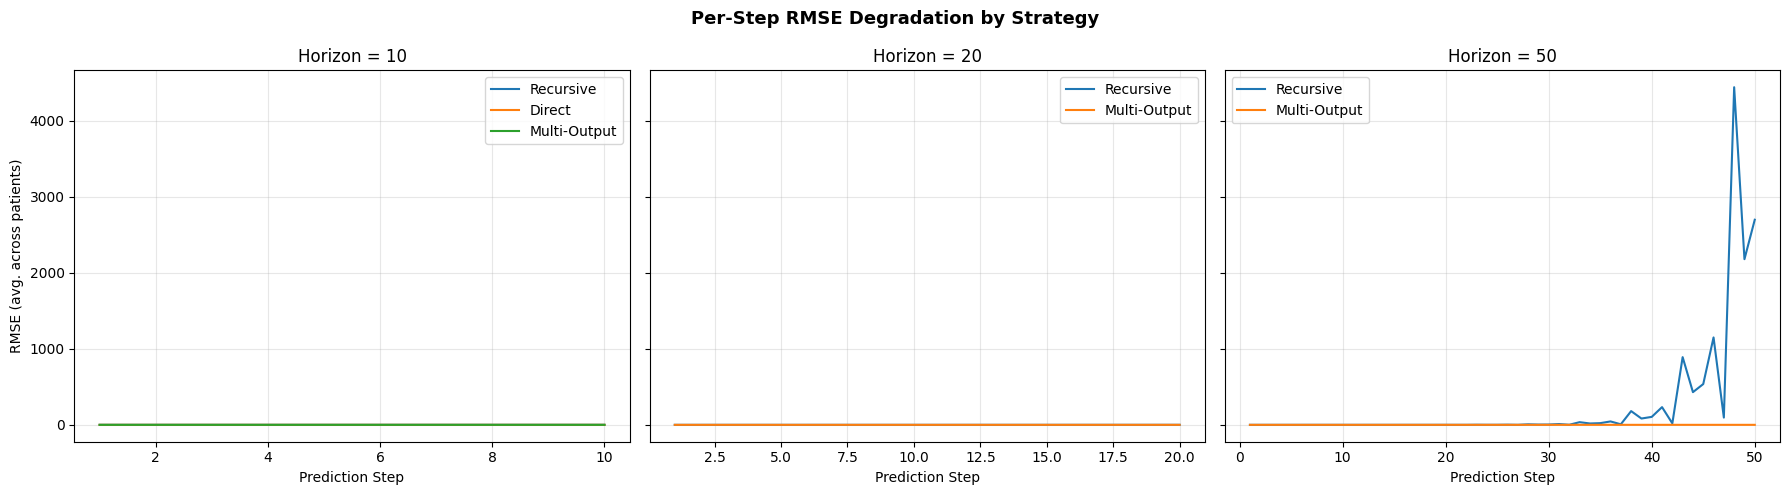

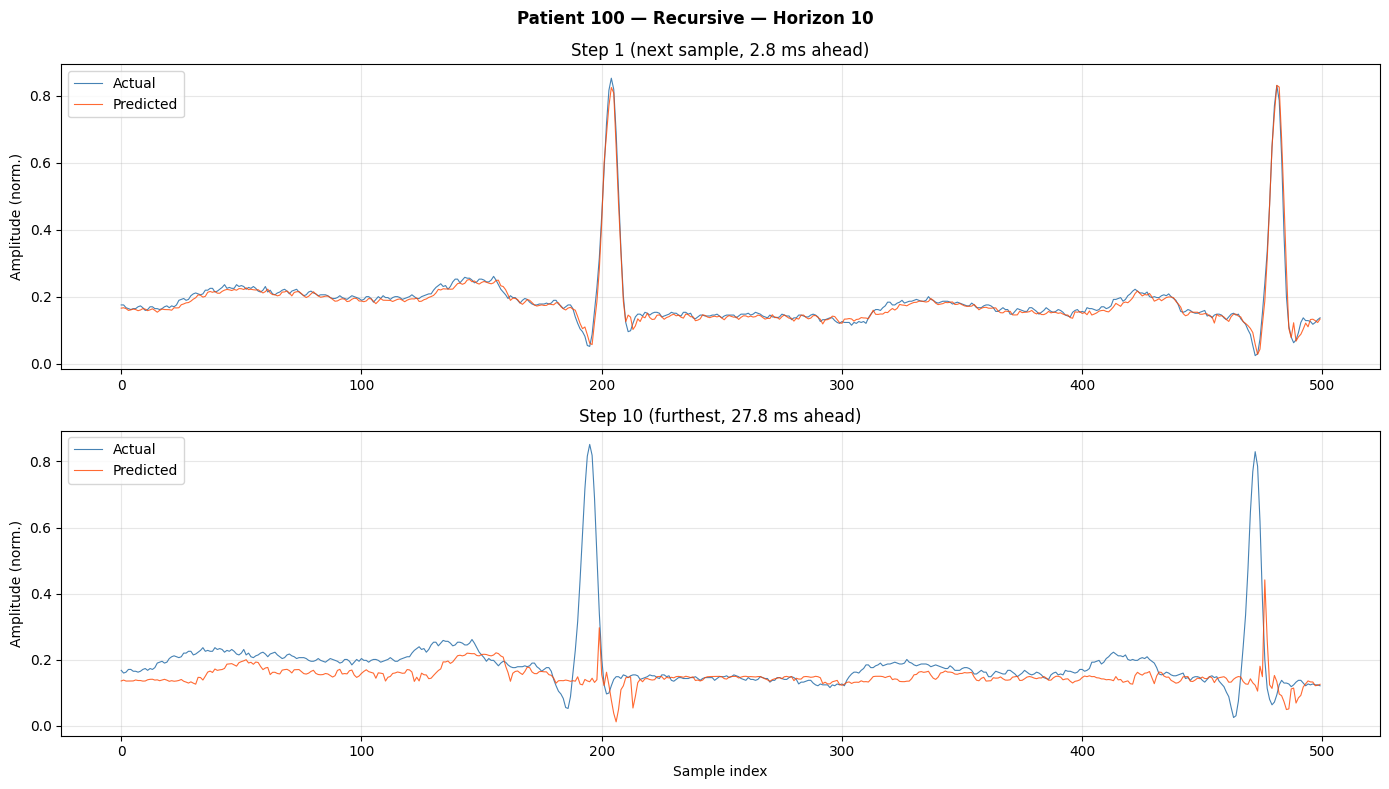

  Saved: plots/pred_100_Recursive_H10.png


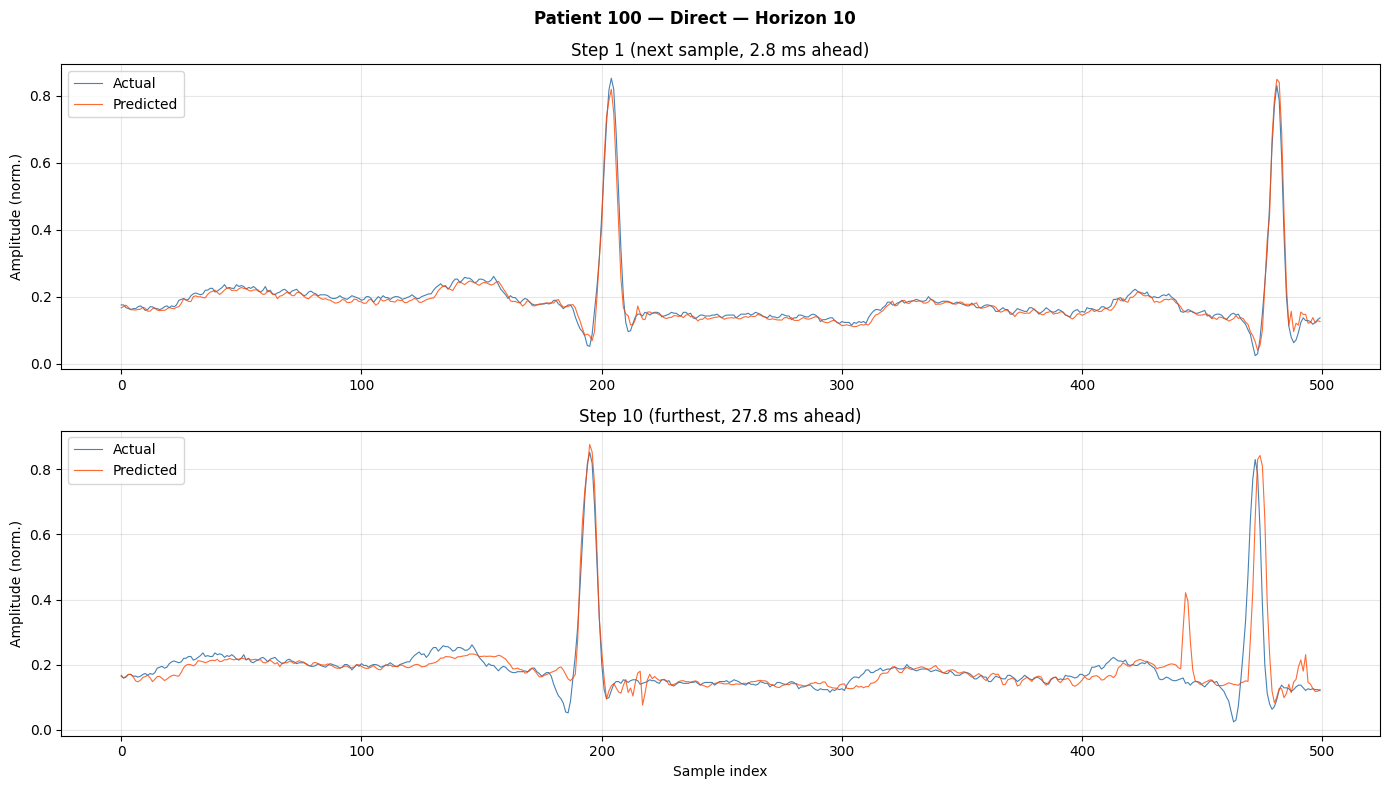

  Saved: plots/pred_100_Direct_H10.png


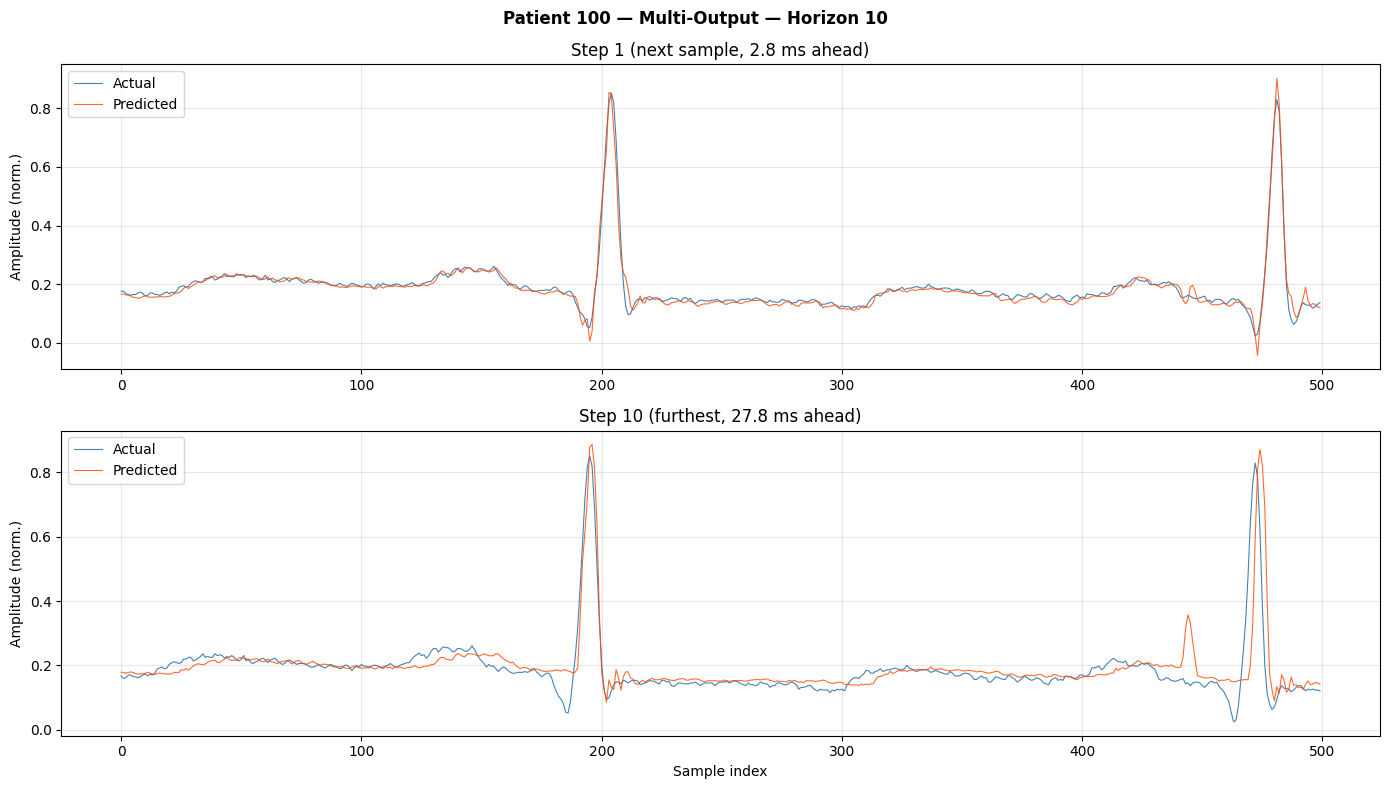

  Saved: plots/pred_100_Multi-Output_H10.png


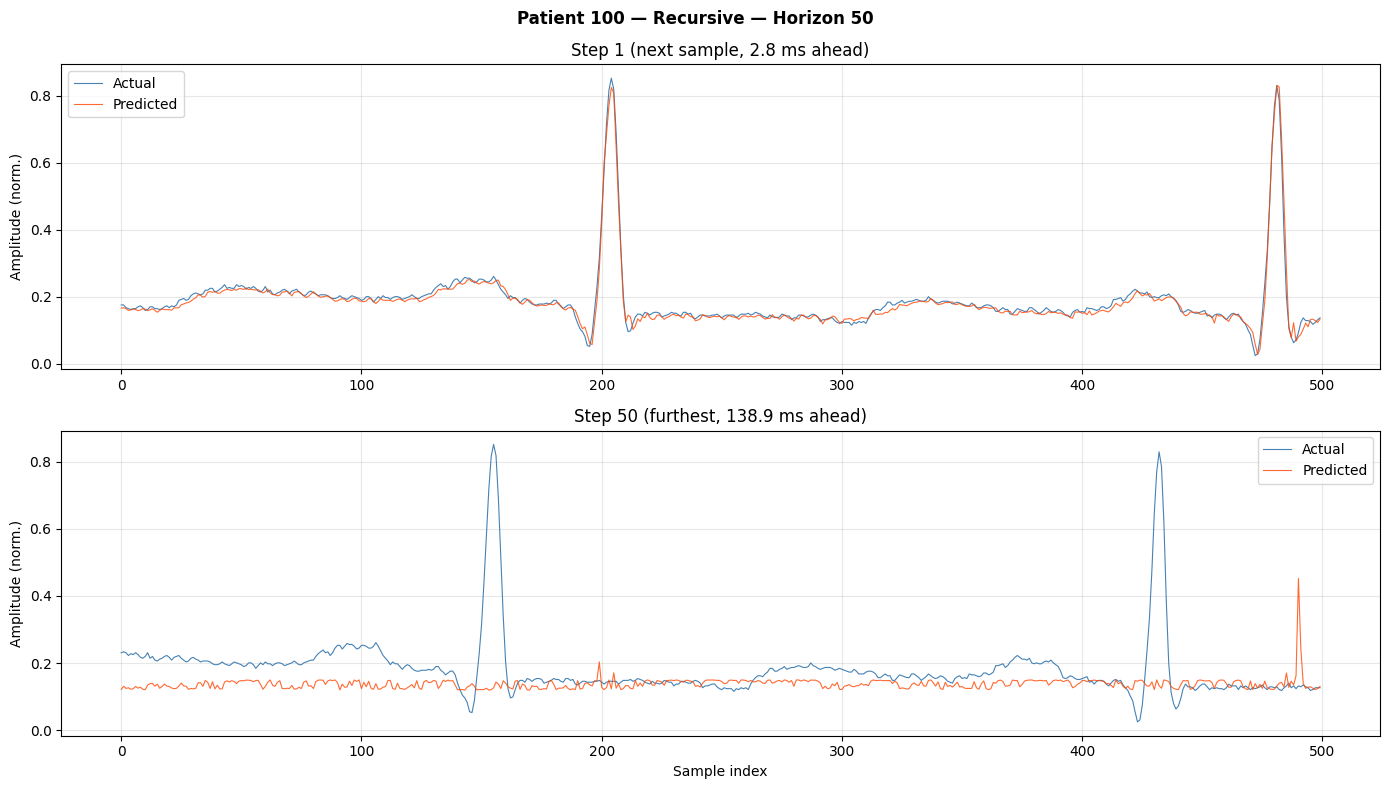

  Saved: plots/pred_100_Recursive_H50.png


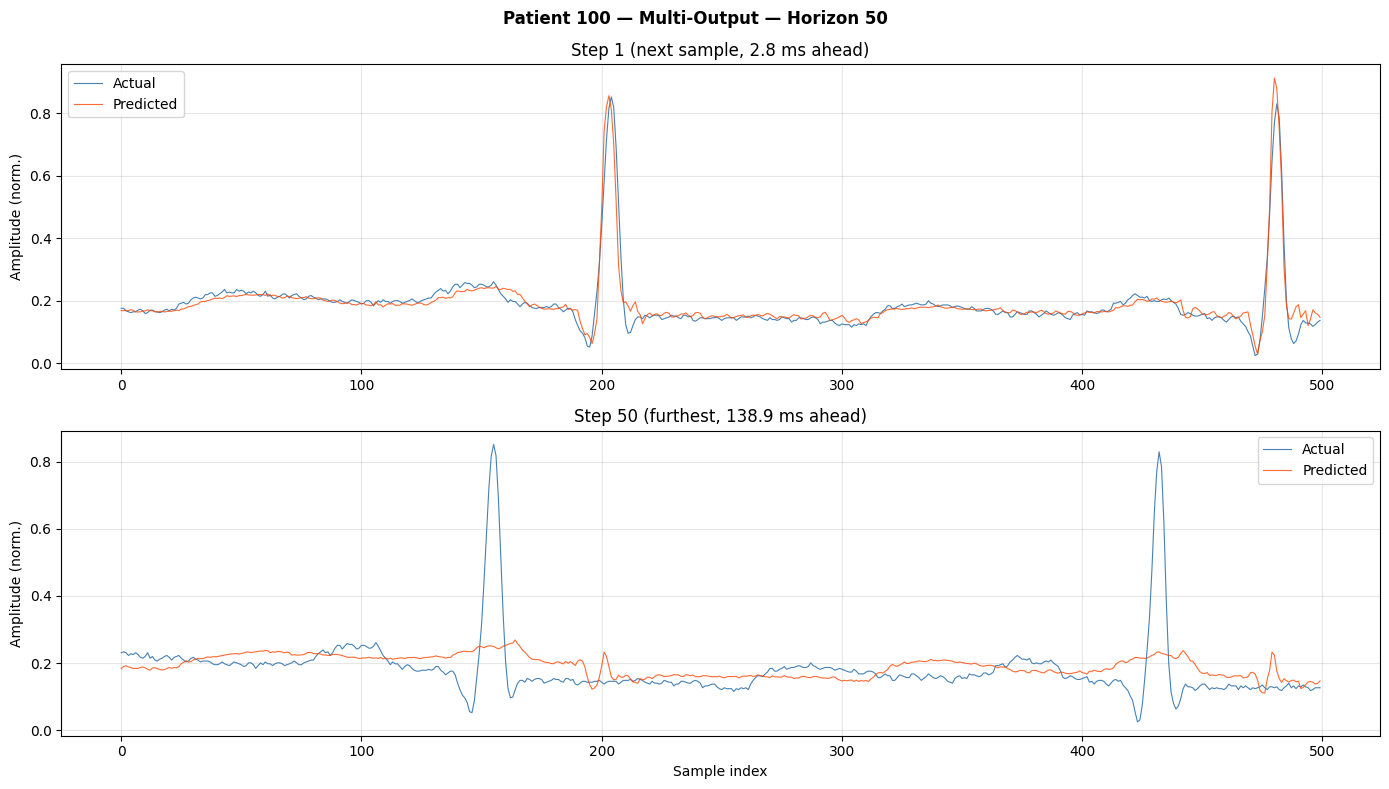

  Saved: plots/pred_100_Multi-Output_H50.png


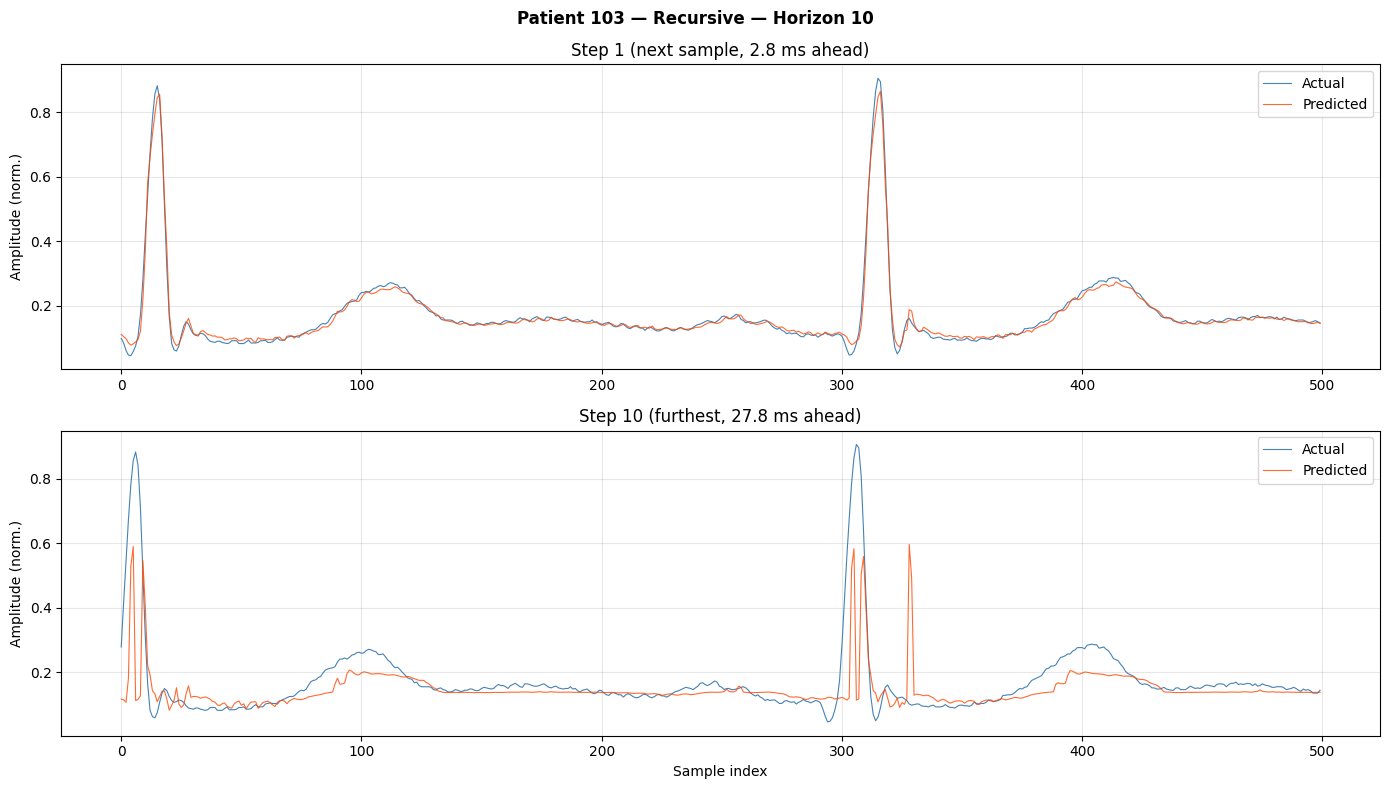

  Saved: plots/pred_103_Recursive_H10.png


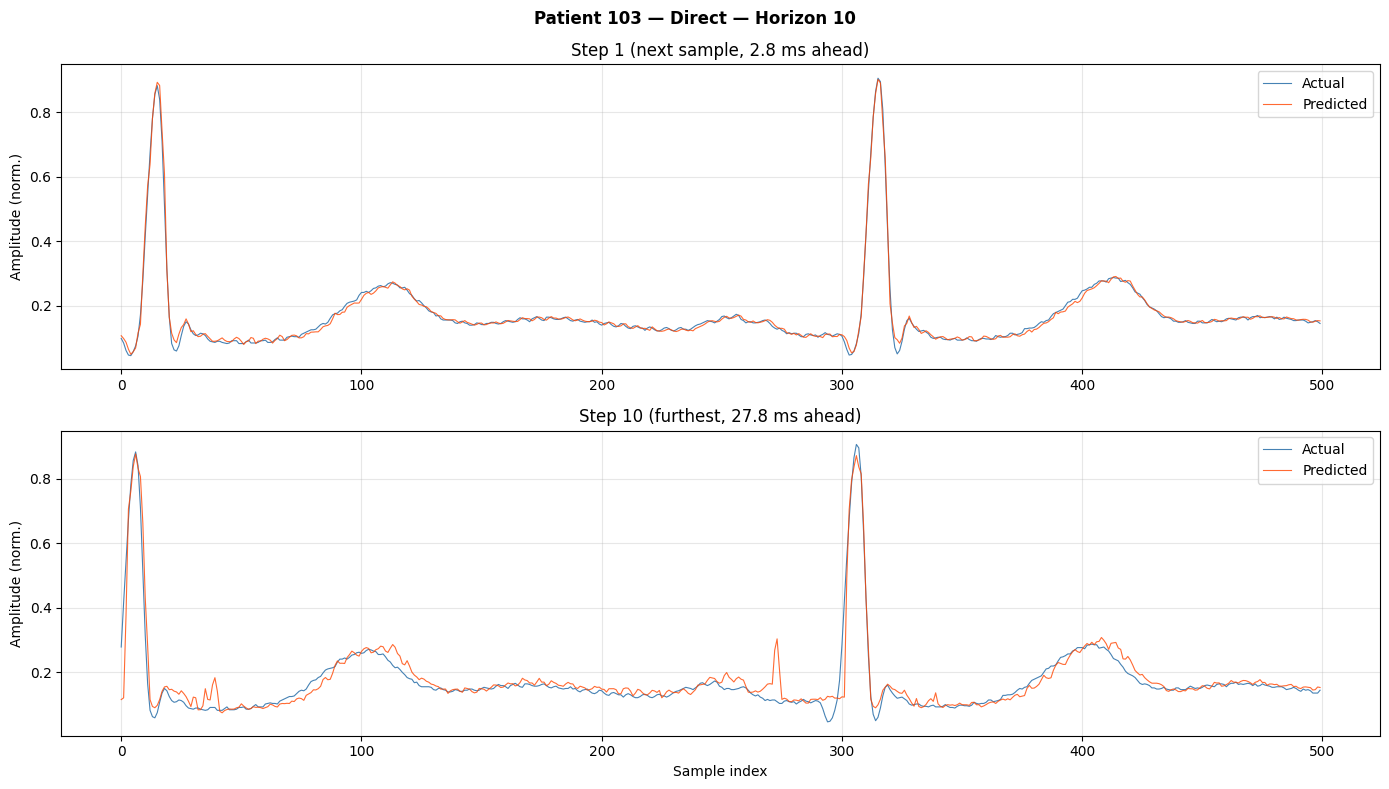

  Saved: plots/pred_103_Direct_H10.png


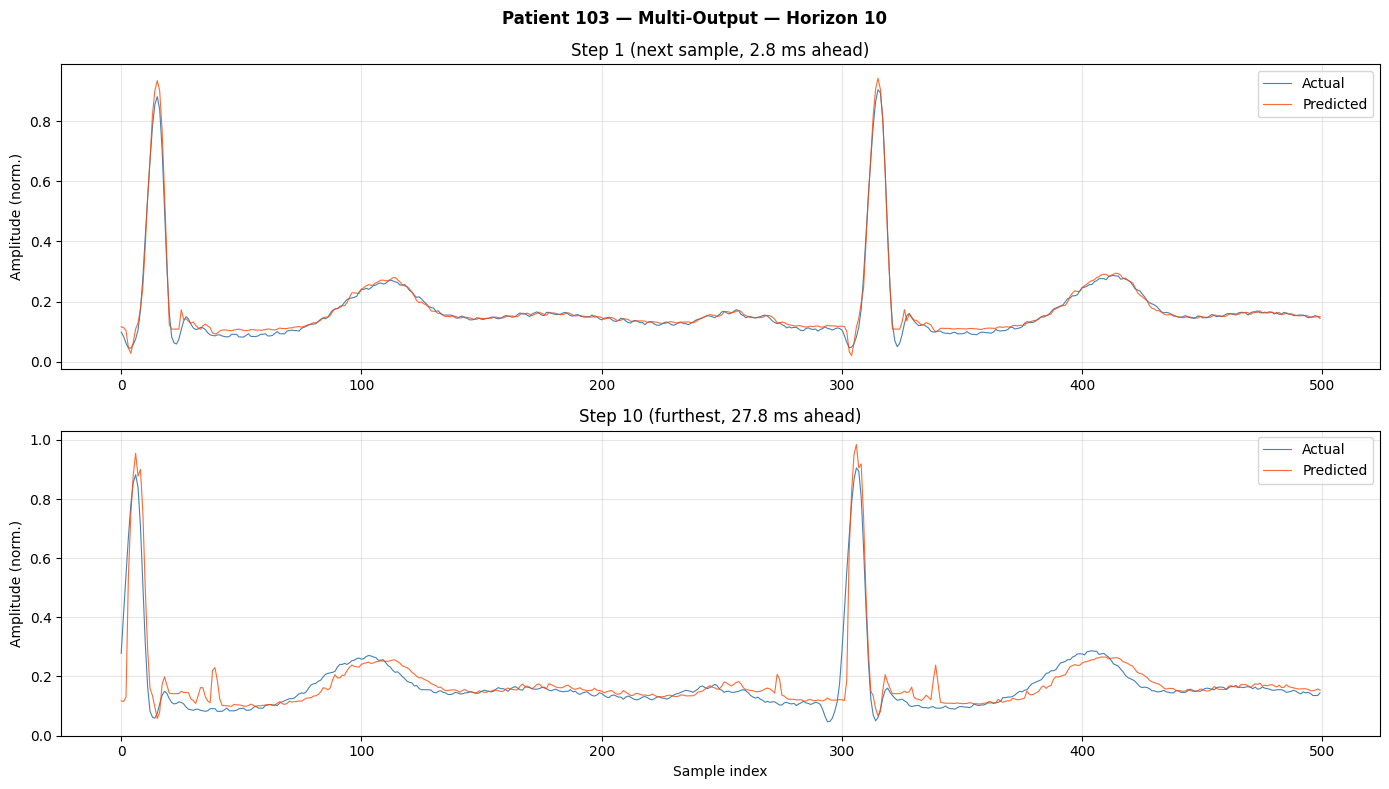

  Saved: plots/pred_103_Multi-Output_H10.png


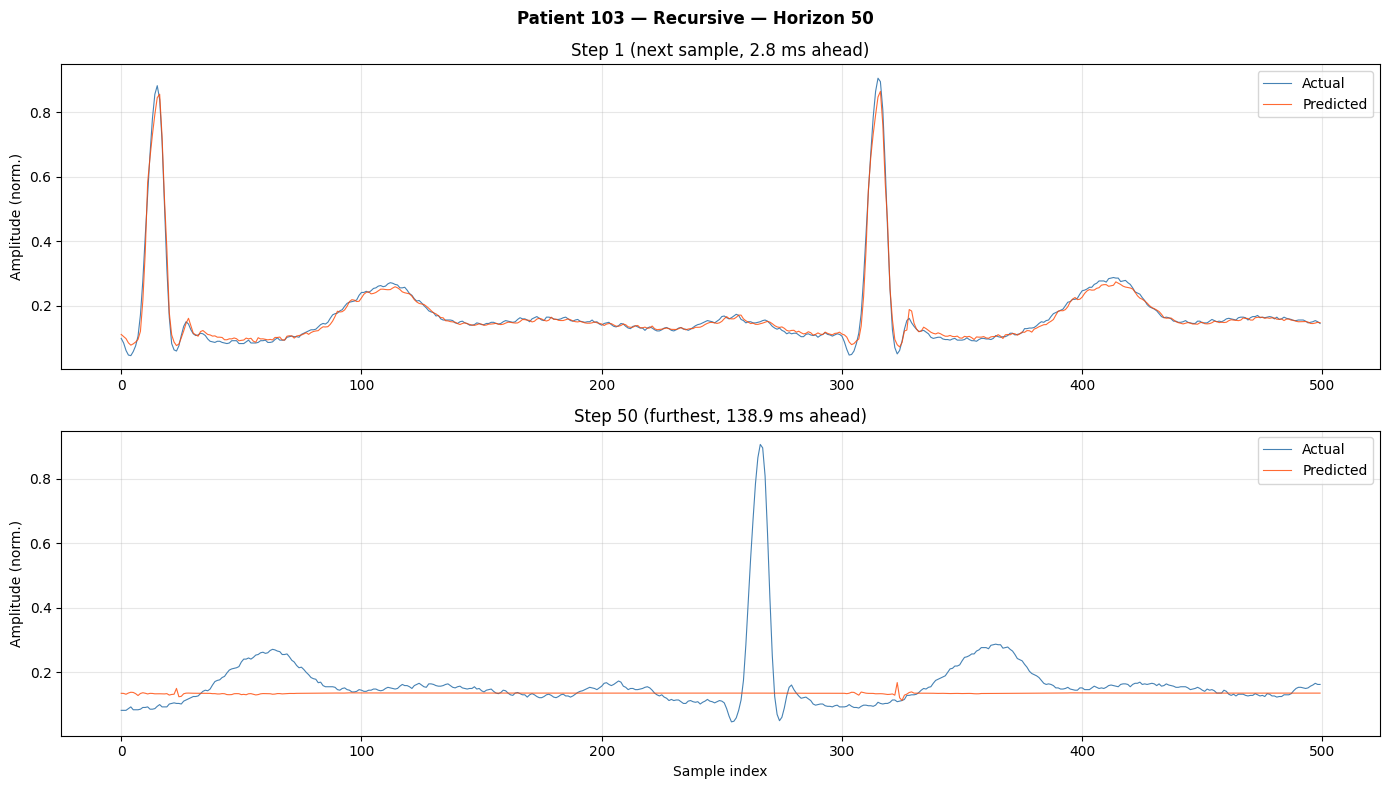

  Saved: plots/pred_103_Recursive_H50.png


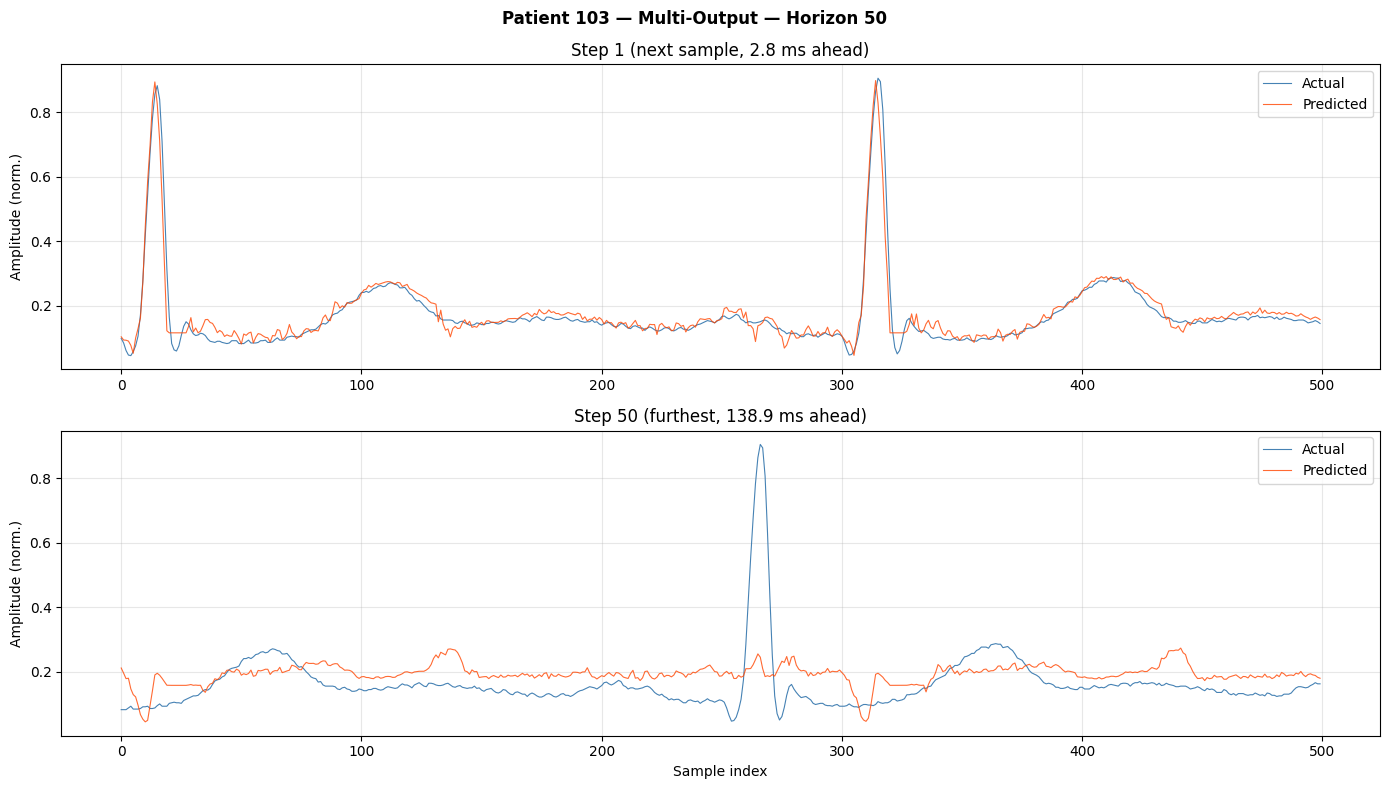

  Saved: plots/pred_103_Multi-Output_H50.png


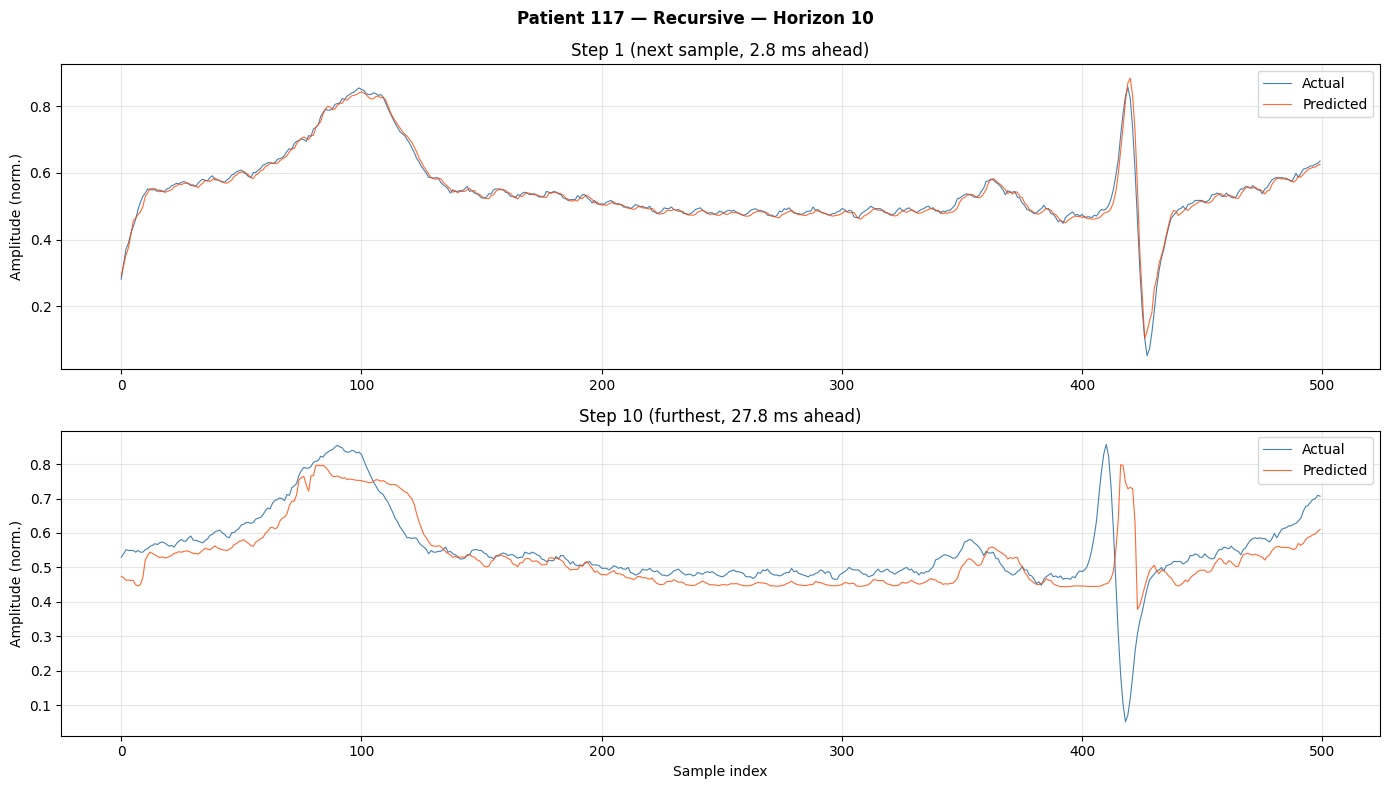

  Saved: plots/pred_117_Recursive_H10.png


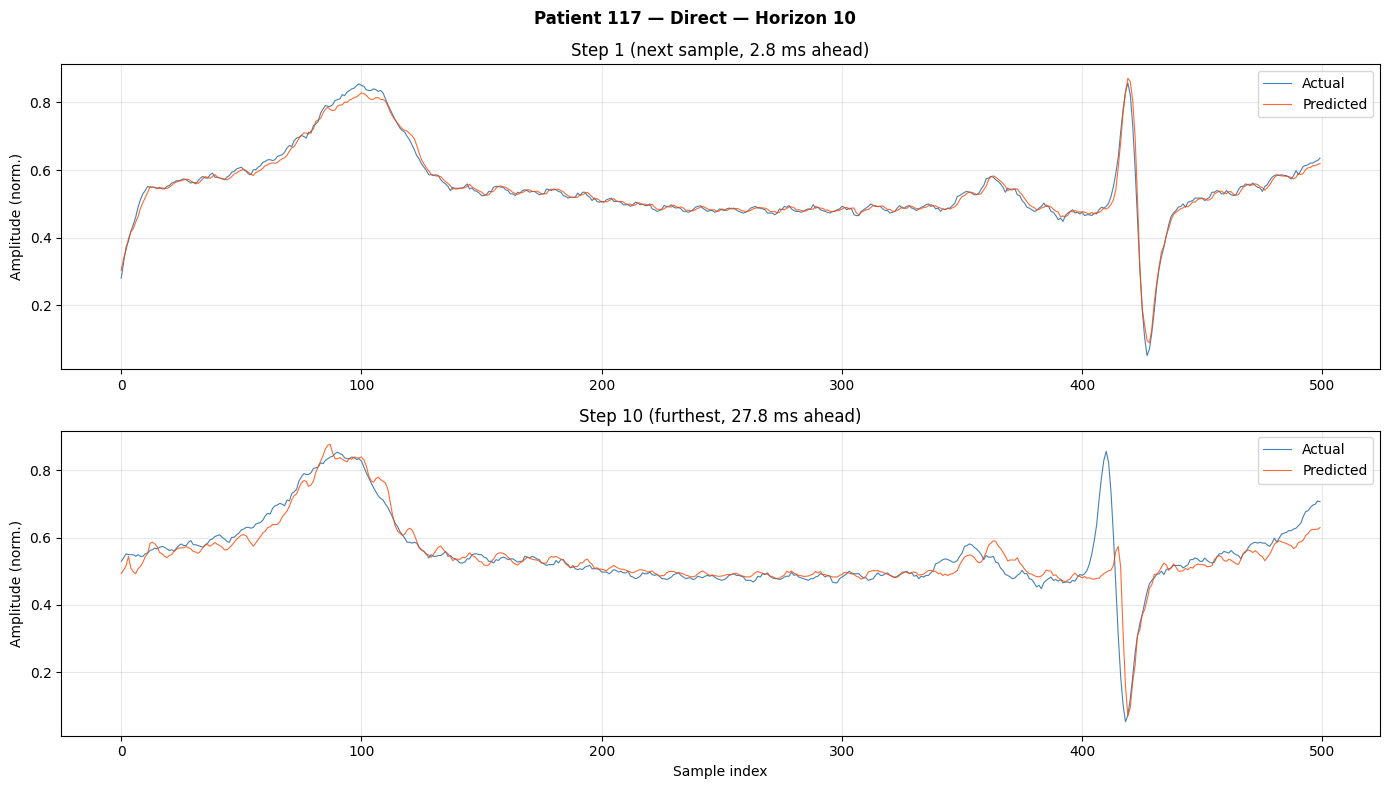

  Saved: plots/pred_117_Direct_H10.png


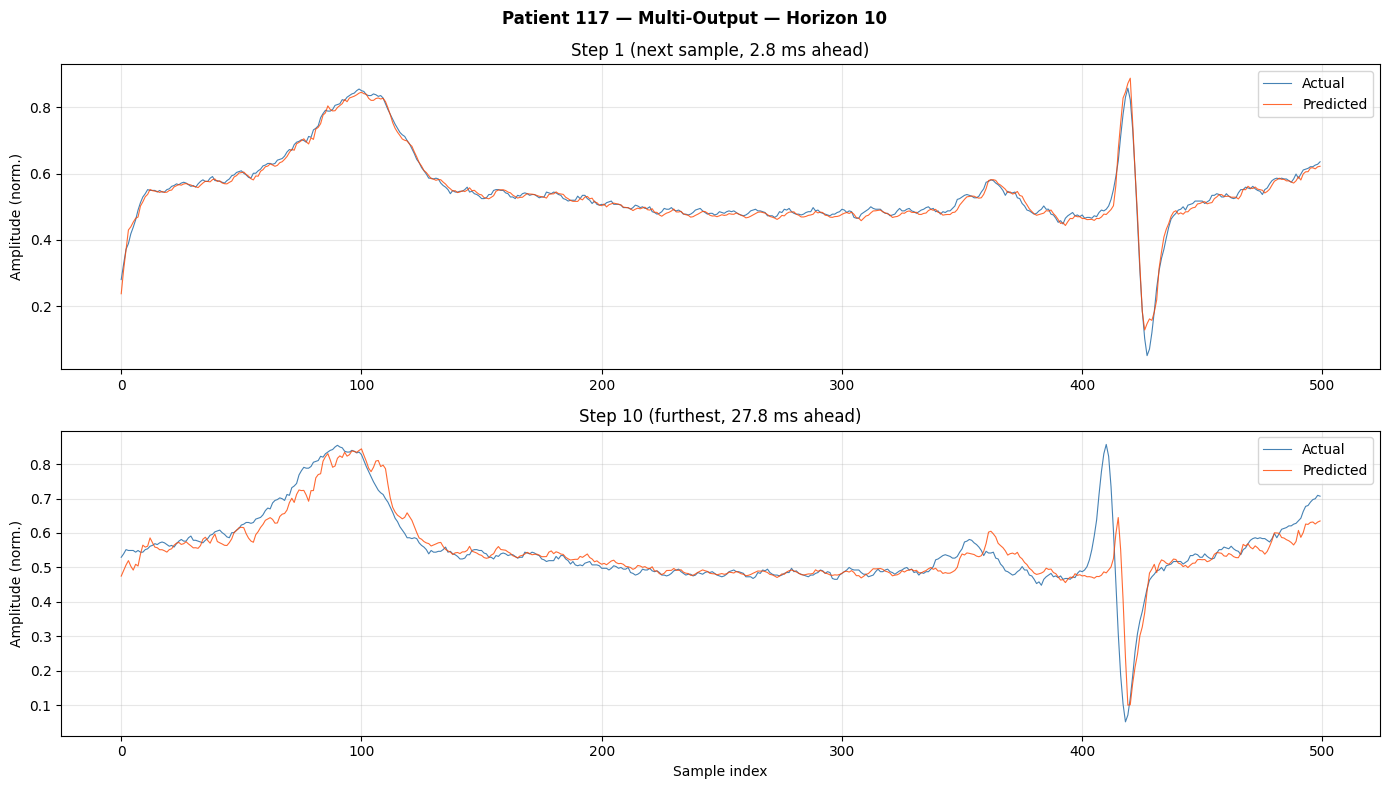

  Saved: plots/pred_117_Multi-Output_H10.png


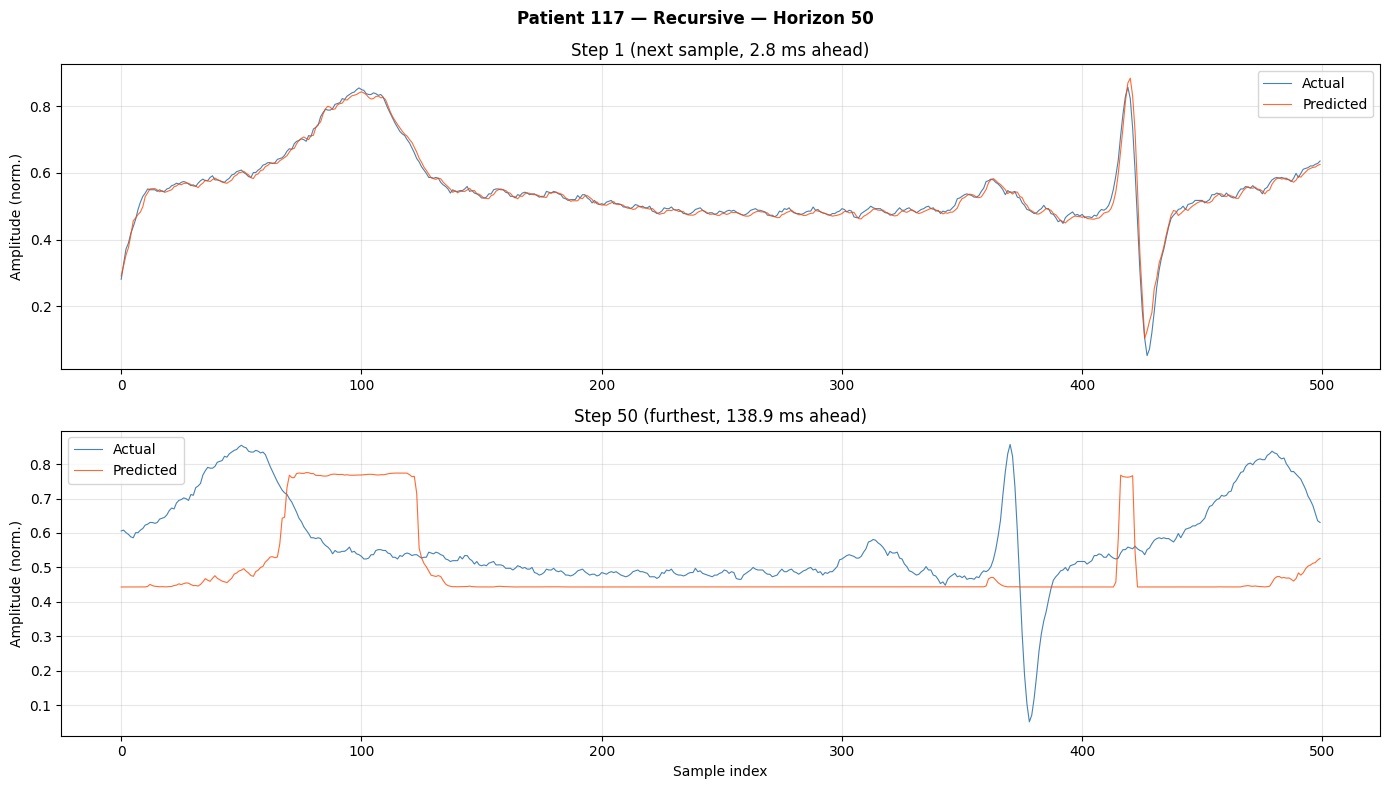

  Saved: plots/pred_117_Recursive_H50.png


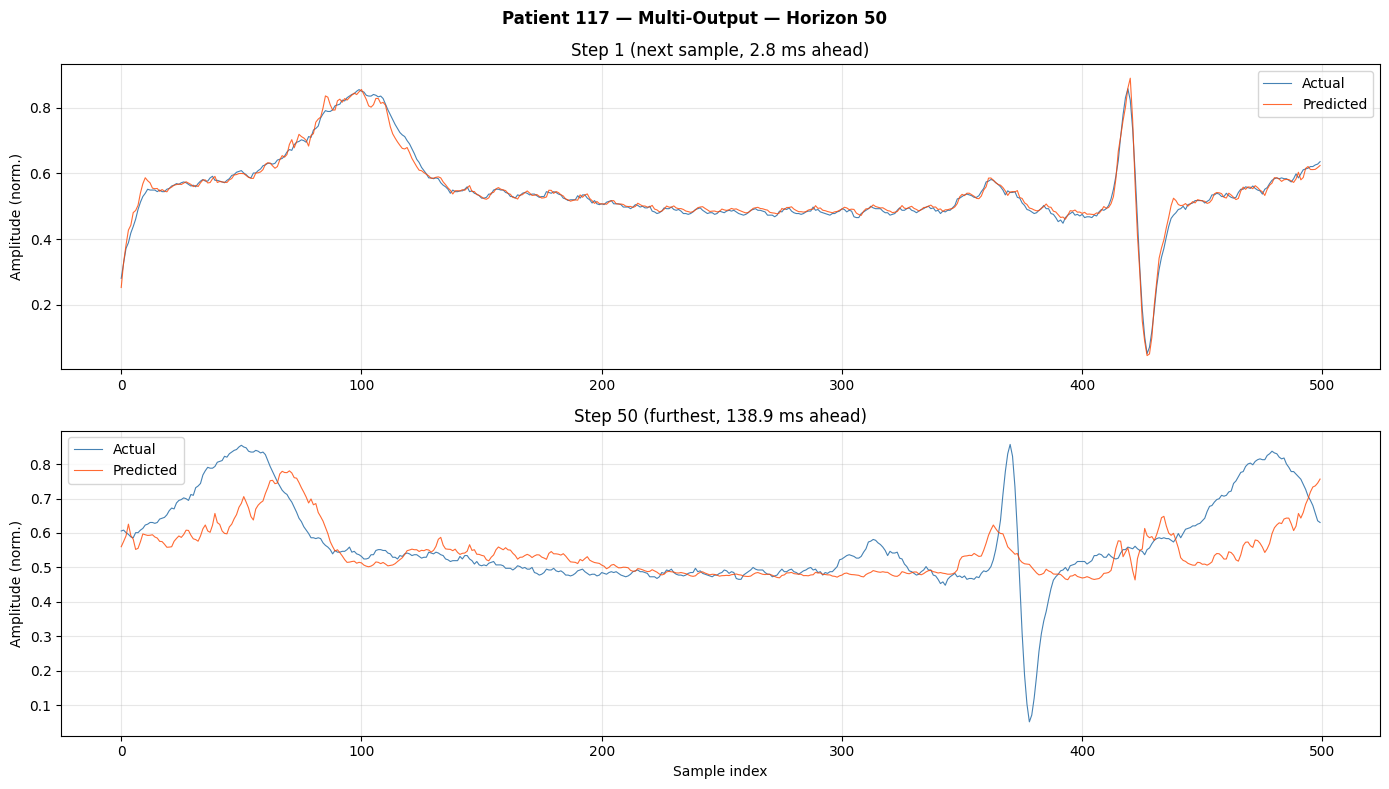

  Saved: plots/pred_117_Multi-Output_H50.png


In [14]:
# --- Per-step RMSE degradation ---
fig, axes = plt.subplots(1, len(HORIZONS),
                         figsize=(6 * len(HORIZONS), 5), sharey=True)

for idx, horizon in enumerate(HORIZONS):
    ax = axes[idx]
    for strat in STRATEGIES:
        step_dfs = [per_step_results[(rid, horizon, strat)]
                    for rid in FORECAST_PATIENTS
                    if (rid, horizon, strat) in per_step_results]
        if not step_dfs:
            continue
        combined = pd.concat(step_dfs)
        avg_by_step = combined.groupby('Step')['RMSE'].mean()
        ax.plot(avg_by_step.index, avg_by_step.values, label=strat, linewidth=1.5)
    ax.set_title(f'Horizon = {horizon}')
    ax.set_xlabel('Prediction Step')
    if idx == 0:
        ax.set_ylabel('RMSE (avg. across patients)')
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle('Per-Step RMSE Degradation by Strategy', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/per_step_rmse.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Actual vs Predicted plots ---
def plot_actual_vs_predicted(rid, horizon, strategy, y_true, y_pred, save_dir='plots'):
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    n_show = min(500, len(y_true))

    axes[0].plot(y_true[:n_show, 0], label='Actual', linewidth=0.8, color='steelblue')
    axes[0].plot(y_pred[:n_show, 0], label='Predicted', linewidth=0.8, color='orangered', alpha=0.8)
    axes[0].set_title(f'Step 1 (next sample, {1/FS*1000:.1f} ms ahead)')
    axes[0].legend(); axes[0].set_ylabel('Amplitude (norm.)'); axes[0].grid(alpha=0.3)

    last = horizon - 1
    axes[1].plot(y_true[:n_show, last], label='Actual', linewidth=0.8, color='steelblue')
    axes[1].plot(y_pred[:n_show, last], label='Predicted', linewidth=0.8, color='orangered', alpha=0.8)
    axes[1].set_title(f'Step {horizon} (furthest, {horizon/FS*1000:.1f} ms ahead)')
    axes[1].legend(); axes[1].set_ylabel('Amplitude (norm.)')
    axes[1].set_xlabel('Sample index'); axes[1].grid(alpha=0.3)

    fig.suptitle(f'Patient {rid} — {strategy} — Horizon {horizon}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    fname = os.path.join(save_dir, f'pred_{rid}_{strategy}_H{horizon}.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {fname}')


VIZ_PATIENTS = ['100', '103', '117']
VIZ_HORIZONS = [10, 50]

for rid in VIZ_PATIENTS:
    for horizon in VIZ_HORIZONS:
        for strat in STRATEGIES:
            key = (rid, horizon, strat)
            if key in saved_preds:
                y_te, preds = saved_preds[key]
                plot_actual_vs_predicted(rid, horizon, strat, y_te, preds)

## 11. Strategy Comparison & Failure Analysis

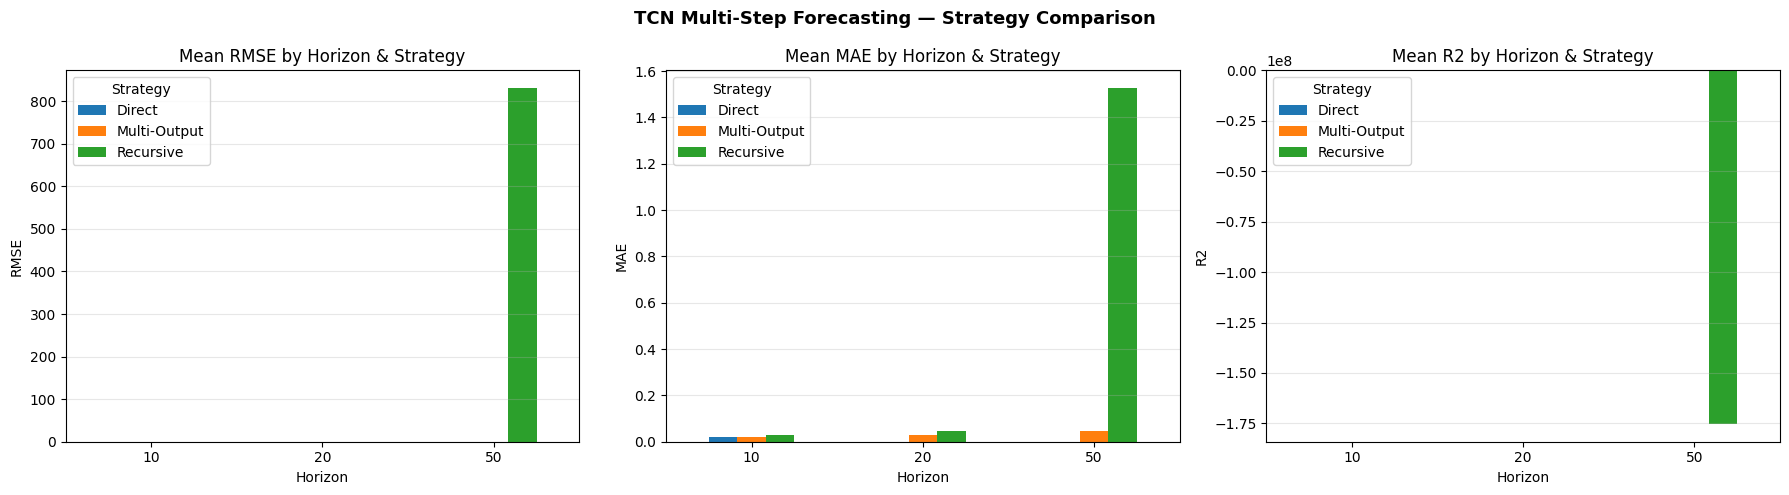


Patients where R² < 0.5

Horizon 10:
Patient  Strategy       R2     RMSE     MAE
    100 Recursive 0.359619 0.076907 0.03525

Horizon 20:
Patient  Strategy        R2     RMSE      MAE
    100 Recursive -0.020344 0.097085 0.049784
    103 Recursive  0.260185 0.099756 0.042869
    105 Recursive  0.383317 0.090549 0.042719
    124 Recursive -7.393832 0.443605 0.048917

Horizon 50:
Patient     Strategy            R2        RMSE      MAE
    100    Recursive -4.033721e+04   19.307881 0.139130
    100 Multi-Output  2.888579e-01    0.081069 0.037666
    103    Recursive -2.545106e-02    0.117371 0.055989
    103 Multi-Output  3.391296e-01    0.094224 0.045399
    105    Recursive  4.414260e-02    0.112761 0.060810
    105 Multi-Output  4.214571e-01    0.087726 0.050720
    109    Recursive  2.777737e-01    0.116740 0.070588
    117    Recursive  1.329628e-01    0.114666 0.077581
    124    Recursive -1.051909e+09 4967.146867 8.755659


Bottom 10 by R² (across all experiments):
Patient  Horiz

In [15]:
# --- Strategy comparison bar chart ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ['RMSE', 'MAE', 'R2']):
    pivot = df_results.pivot_table(
        index='Horizon', columns='Strategy', values=metric, aggfunc='mean'
    )
    pivot.plot(kind='bar', ax=ax, rot=0)
    ax.set_title(f'Mean {metric} by Horizon & Strategy')
    ax.set_ylabel(metric)
    ax.set_xlabel('Horizon')
    ax.legend(title='Strategy')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('TCN Multi-Step Forecasting — Strategy Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Failure analysis ---
R2_FAIL_THRESH = 0.5
print(f'\nPatients where R² < {R2_FAIL_THRESH}')
print('=' * 60)

for h in HORIZONS:
    df_h = df_results[df_results['Horizon'] == h]
    fails = df_h[df_h['R2'] < R2_FAIL_THRESH]
    if len(fails):
        print(f'\nHorizon {h}:')
        print(fails[['Patient', 'Strategy', 'R2', 'RMSE', 'MAE']].to_string(index=False))
    else:
        print(f'\nHorizon {h}: all R² ≥ {R2_FAIL_THRESH}')

print('\n\nBottom 10 by R² (across all experiments):')
print(df_results.nsmallest(10, 'R2')
      [['Patient', 'Horizon', 'Strategy', 'R2', 'RMSE', 'MAE']]
      .to_string(index=False))

print('\n\nBest strategy per horizon (mean R²):')
best = df_results.groupby(['Horizon', 'Strategy'])['R2'].mean().reset_index()
for h in HORIZONS:
    bh = best[best['Horizon'] == h].sort_values('R2', ascending=False).iloc[0]
    print(f'  H={h:2d} : {bh["Strategy"]:<14s}  mean R² = {bh["R2"]:.4f}')

In [16]:
print('\n' + '=' * 80)
print('EXPERIMENT COMPLETE')
print('=' * 80)
print(f'Patients         : {len(PATIENTS)}')
print(f'Horizons         : {HORIZONS}')
print(f'Strategies       : {STRATEGIES}')
print(f'Total experiments : {len(df_results)}')
print(f'Results CSV      : tcn_forecasting_results.csv')
print(f'Plots directory  : plots/')
print()
print('Horizon interpretations (at 360 Hz sampling):')
for h in HORIZONS:
    ms = h / FS * 1000
    print(f'  H={h:2d} → {ms:.1f} ms ≈ {h/FS:.3f} s into the future')


EXPERIMENT COMPLETE
Patients         : 21
Horizons         : [10, 20, 50]
Strategies       : ['Recursive', 'Direct', 'Multi-Output']
Total experiments : 42
Results CSV      : tcn_forecasting_results.csv
Plots directory  : plots/

Horizon interpretations (at 360 Hz sampling):
  H=10 → 27.8 ms ≈ 0.028 s into the future
  H=20 → 55.6 ms ≈ 0.056 s into the future
  H=50 → 138.9 ms ≈ 0.139 s into the future
